# 05 · IC timeseries from GEE (Moscardo catchment)

This notebook demonstrates `GEEFetcher.fetch_timeseries()` and computes a temporal sequence of Connectivity Index (IC) maps for the Moscardo catchment (Italian Alps).

## 1 · Configuration

In [12]:
from pathlib import Path

# Small area in Chambal Catchment, India
BOUNDS = (76.09556906553738, 24.867882347223897, 76.52756888567045, 25.178609604000833) #<-- Chambal

# Use projected CRS in meters for slope/routing reliability
CRS = "EPSG:32643"

START_DATE = "2022-01-01"
END_DATE = "2022-12-31"

# Temporal resampling options: 'monthly' | 'seasonal' | 'annual'
TEMPORAL_RESAMPLING = "monthly"

# DEM/NDVI target fetch scale in meters
SCALE = 30

FLOW_DIRECTOR = "DINF"
W_MIN = 0.005
W_MAX = 1.0

# Replace if your EE setup requires an explicit project
GEE_PROJECT = "drylands-aberuni"

OUT_DIR = Path("output_nb5")
OUT_DIR.mkdir(exist_ok=True)
OUT_DIR

PosixPath('output_nb5')

In [13]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from landlab import RasterModelGrid
from geomorphconn.gee import GEEFetcher
from geomorphconn.components import ConnectivityIndex
from geomorphconn.weights import preset_rainfall_ndvi

## 2 · Fetch NDVI/Rainfall timeseries windows from GEE

In [14]:
fetcher = GEEFetcher(
    bounds=BOUNDS,
    dem_source="COPDEM30",
    rainfall_source="CHIRPS",
    ndvi_source="Landsat8",
    start_date=START_DATE,
    end_date=END_DATE,
    scale=SCALE,
    crs=CRS,
    gee_project=GEE_PROJECT,
)

ts = fetcher.fetch_timeseries(resampling=TEMPORAL_RESAMPLING)
dem = ts["dem"]
profile = ts["profile"]
periods = ts["periods"]

nrows, ncols = dem.shape
print(f"Fetched {len(periods)} periods ({TEMPORAL_RESAMPLING})")
print(f"DEM shape: {dem.shape}, dx={abs(profile['transform'].a):.2f} m")
print("First period:", periods[0]["label"], periods[0]["start_date"], periods[0]["end_date"])

GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Landsat 8 Collection 2 SR (~30 m)
  Land cover : None (not fetched)
  Period     : 2022-01-01 → 2022-12-31
  Scale      : 30 m  |  CRS: EPSG:32643
Fetching DEM (shared across all periods) …
  DEM shape: 1161×1442, range: 214.2–326.3 m
[1/12] Fetching window 2022-01: 2022-01-01 → 2022-01-31
  NDVI shape: (1161, 1442), range: -0.128–0.616
  Rainfall shape: (1161, 1442), range: 11.95–17.36
[2/12] Fetching window 2022-02: 2022-02-01 → 2022-02-28
  NDVI shape: (1161, 1442), range: -0.106–0.553
  Rainfall shape: (1161, 1442), range: 0.00–0.00
[3/12] Fetching window 2022-03: 2022-03-01 → 2022-03-31
  NDVI shape: (1161, 1442), range: -0.091–0.495
  Rainfall shape: (1161, 1442), range: 0.00–2.92
[4/12] Fetching window 2022-04: 2022-04-01 → 2022-04-30
  NDVI shape: (1161, 1442), range: -0.108–0.426
  Rainfall shape: (1161, 1442), range: 0.00–0.00
[5/12] Fetching 

## 3 · Build Landlab grid once (shared DEM)

In [15]:
tr = profile["transform"]
x_min = tr.c
y_min = tr.f - nrows * abs(tr.e)
dx = abs(tr.a)

grid = RasterModelGrid(
    (nrows, ncols),
    xy_spacing=dx,
    xy_of_lower_left=(x_min, y_min),
)

dem_ll = np.flipud(dem).copy()
dem_ll[np.isnan(dem_ll)] = np.nanmin(dem_ll) - 1.0
grid.add_field("topographic__elevation", dem_ll.ravel(), at="node")

print(f"Grid nodes: {grid.number_of_nodes:,}")

Grid nodes: 1,674,162


## 4 · Compute IC for each period

For each temporal window, IC is computed with rainfall+NDVI weight (`preset_rainfall_ndvi`).

In [16]:
def to_node(arr2d):
    a = np.flipud(arr2d).copy()
    a[np.isnan(a)] = 0.0
    return a.ravel()

records = []
ic_maps = []

for p in periods:
    ndvi_nodes = to_node(p["ndvi"])

    rf_nodes = to_node(p["rainfall"])

    wb = preset_rainfall_ndvi(rf_nodes, ndvi_nodes, w_min=W_MIN)
    ic = ConnectivityIndex(
        grid,
        flow_director=FLOW_DIRECTOR,
        weight=wb,
        w_min=W_MIN,
        w_max=W_MAX,
    )
    ic.run_one_step()

    # Copy the field snapshot so later timesteps do not overwrite earlier maps.
    ic_arr = ic.IC.reshape(grid.shape).copy()
    ic_maps.append(ic_arr)

    vals = ic_arr[np.isfinite(ic_arr)]
    records.append({
        "label": p["label"],
        "start_date": p["start_date"],
        "end_date": p["end_date"],
        "ic_mean": float(np.mean(vals)),
        "ic_median": float(np.median(vals)),
        "ic_p10": float(np.percentile(vals, 10)),
        "ic_p90": float(np.percentile(vals, 90)),
        "ic_std": float(np.std(vals)),
    })

df_ts = pd.DataFrame(records)
df_ts

,label,start_date,end_date,ic_mean,ic_median,ic_p10,ic_p90,ic_std
0,2022-01,2022-01-01,2022-01-31,-7.634343,-7.723442,-8.543797,-6.619595,0.771483
1,2022-02,2022-02-01,2022-02-28,-7.469342,-7.581718,-8.198078,-6.589126,0.663888
2,2022-03,2022-03-01,2022-03-31,-8.079095,-8.172396,-8.807543,-7.235106,0.652510
3,2022-04,2022-04-01,2022-04-30,-7.394534,-7.502318,-8.122781,-6.518667,0.658893
4,2022-05,2022-05-01,2022-05-31,-7.442915,-7.515390,-8.337922,-6.439974,0.754314
5,2022-06,2022-06-01,2022-06-30,-7.359600,-7.448468,-8.232050,-6.384849,0.740948
6,2022-07,2022-07-01,2022-07-31,-7.348778,-7.434585,-8.107052,-6.470825,0.665375
7,2022-08,2022-08-01,2022-08-31,-7.336784,-7.451094,-8.014152,-6.520077,0.630078
8,2022-09,2022-09-01,2022-09-30,-7.568305,-7.692426,-8.356538,-6.628004,0.708182
9,2022-10,2022-10-01,2022-10-31,-7.543380,-7.682723,-8.344727,-6.563335,0.725131


## 5 · Temporal IC behaviour plots

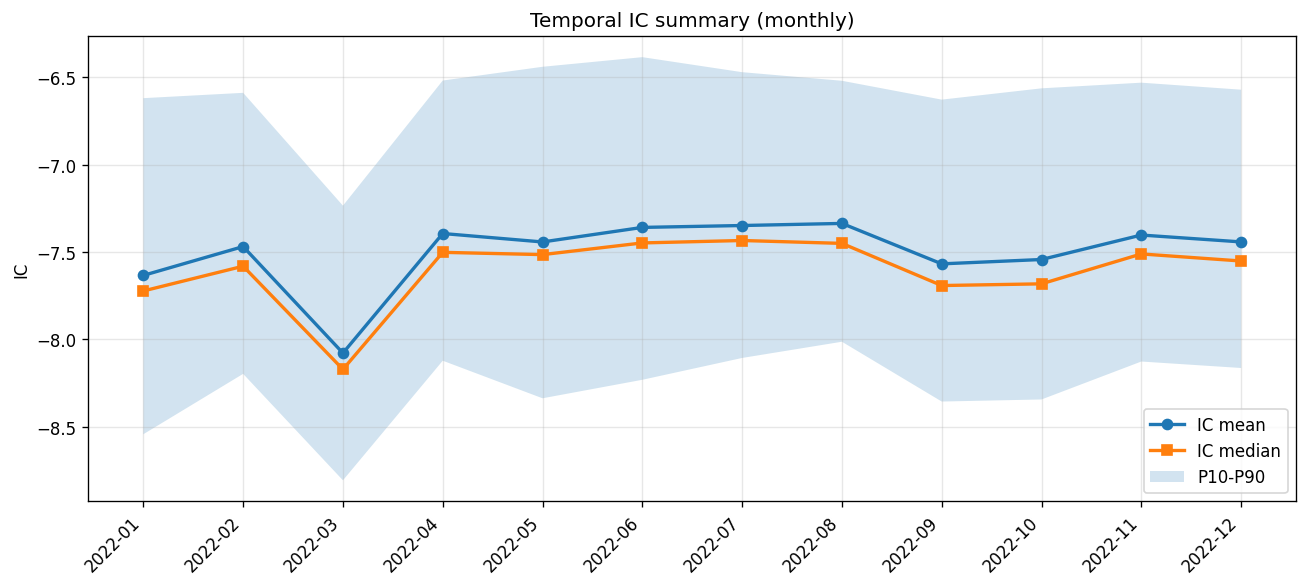

In [39]:
x = np.arange(len(df_ts))

fig, ax = plt.subplots(figsize=(11, 5), dpi=120)
ax.plot(x, df_ts["ic_mean"], marker="o", label="IC mean", linewidth=2)
ax.plot(x, df_ts["ic_median"], marker="s", label="IC median", linewidth=2)
ax.fill_between(x, df_ts["ic_p10"], df_ts["ic_p90"], alpha=0.2, label="P10-P90")

ax.set_xticks(x)
ax.set_xticklabels(df_ts["label"], rotation=45, ha="right")
ax.set_ylabel("IC")
ax.set_title(f"Temporal IC summary ({TEMPORAL_RESAMPLING})")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()

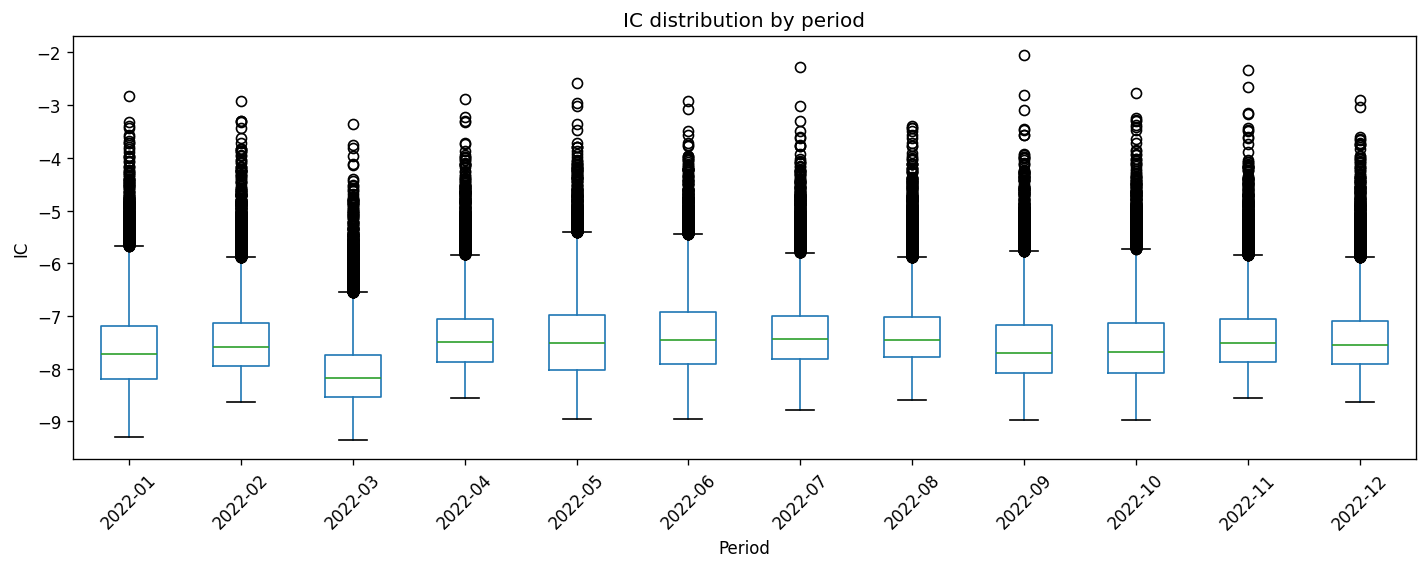

In [38]:
# Distribution-by-period boxplot
flat = []
for i, label in enumerate(df_ts["label"]):
    vals = ic_maps[i][np.isfinite(ic_maps[i])]
    sample = vals if vals.size <= 25000 else vals[np.random.choice(vals.size, 25000, replace=False)]
    flat.extend([(label, v) for v in sample])

df_box = pd.DataFrame(flat, columns=["label", "IC"])

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
df_box.boxplot(column="IC", by="label", ax=ax, rot=45, grid=False)
ax.set_title("IC distribution by period")
ax.set_xlabel("Period")
ax.set_ylabel("IC")
plt.suptitle("")
plt.tight_layout(); plt.show()

## 6 · Map snapshots for selected periods

Text(0.5, 0.98, 'IC map evolution through time')

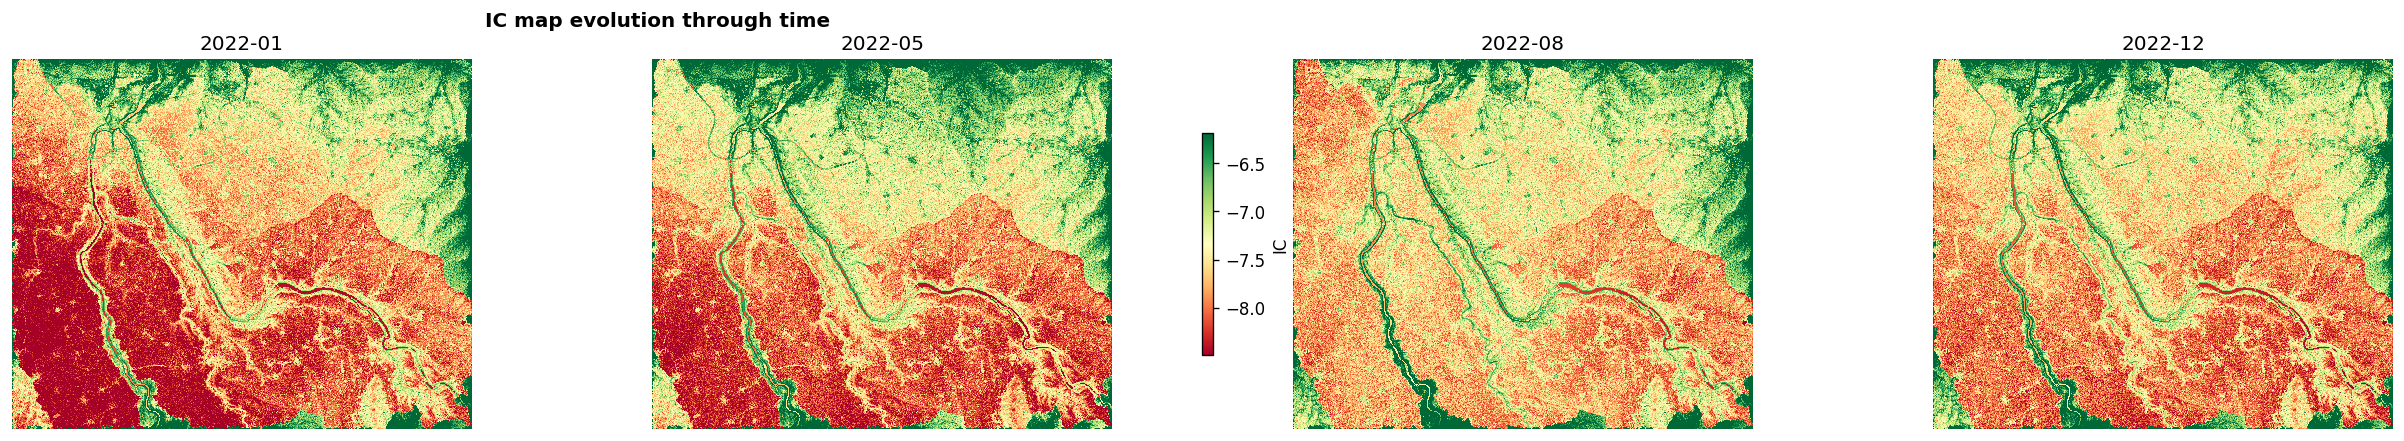

In [37]:
n_show = min(4, len(ic_maps))
idxs = np.linspace(0, len(ic_maps) - 1, n_show).round().astype(int)

fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4), dpi=120)
if n_show == 1:
    axes = [axes]

vmin = np.nanpercentile(np.stack(ic_maps), 5)
vmax = np.nanpercentile(np.stack(ic_maps), 95)
im = None

for ax, i in zip(axes, idxs):
    im = ax.imshow(np.flipud(ic_maps[i]), cmap="RdYlGn", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(df_ts.loc[i, "label"])
    ax.axis("off")

if im is not None:
    fig.colorbar(im, ax=axes, shrink=0.6, label="IC", pad=-0.8)
plt.suptitle("IC map evolution through time", fontweight="bold")
# plt.tight_layout(); plt.show()

In [20]:
df_ts.to_csv(OUT_DIR / f"ic_timeseries_{TEMPORAL_RESAMPLING}.csv", index=False)
print("Saved:", (OUT_DIR / f"ic_timeseries_{TEMPORAL_RESAMPLING}.csv").resolve())

Saved: /mnt/e/SideResearch/softwares/IndexOfConnectivity/sedconn_v3/sedconn/notebooks/output_nb5/ic_timeseries_monthly.csv
